In [ ]:
import random
import os
from pathlib import Path
import json
from concurrent.futures import ThreadPoolExecutor
import multiprocessing
import threading
import pandas as pd
import numpy as np
import statsmodels as sm
import matplotlib.pyplot as plt
import pmdarima as pm
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler


In [2]:
# Random Seed
random.seed(42)

In [3]:
# Parent directory for data loading
parent_dir = Path.cwd().parent.parent

In [4]:
# Import datasets and drop any nulls for clean processing
final_gig_m_df = pd.read_csv(os.path.join(parent_dir, 'data', 'final', 'gig_monthly_data.csv')).dropna().reset_index(drop=True)
final_sp500_m_df = pd.read_csv(os.path.join(parent_dir, 'data', 'final', 'sp500_monthly_data.csv')).dropna().reset_index(drop=True)

In [5]:
# See correlation_analysis_for_regression.ipynb for how these columns were selected
# Partially based on correlation and partially based on an understanding of the different meanings behind economic indicators
columns_to_keep = ['cpi_data_monthly', # SA
'rec_smooth_prob_data_monthly', # NSA -- but I don't think recessions are seasonal
'unemployment_data_monthly', # SA
'interest_rate_mtg_data_weekly', # NSA
'consumer_sentiment_data_monthly', # NSA
#'Ticker',
'date',
'target'#, # Normalized by dividing closing price with cpi
]

In [6]:
# Reduce datasets to only use columns to keep and set date as index
final_gig_m_df = final_gig_m_df[columns_to_keep]
final_sp500_m_df = final_sp500_m_df[columns_to_keep]

In [7]:
final_gig_m_df = final_gig_m_df.groupby(['date'
                        ,'cpi_data_monthly'
                        ,'rec_smooth_prob_data_monthly'
                        ,'unemployment_data_monthly'
                        ,'interest_rate_mtg_data_weekly'
                        ,'consumer_sentiment_data_monthly']).sum('target')
scaler = StandardScaler()
final_gig_m_df['target'] = scaler.fit_transform(final_gig_m_df['target'].to_frame())
final_gig_m_df.reset_index(inplace=True)
final_gig_m_df['date'] = pd.to_datetime(final_gig_m_df['date'])
final_gig_m_df.set_index('date', inplace=True)

final_sp500_m_df = final_sp500_m_df.groupby(['date'
                        ,'cpi_data_monthly'
                        ,'rec_smooth_prob_data_monthly'
                        ,'unemployment_data_monthly'
                        ,'interest_rate_mtg_data_weekly'
                        ,'consumer_sentiment_data_monthly']).sum('target')
scaler = StandardScaler()
final_sp500_m_df['target'] = scaler.fit_transform(final_sp500_m_df['target'].to_frame())
final_sp500_m_df.reset_index(inplace=True)
final_sp500_m_df['date'] = pd.to_datetime(final_sp500_m_df['date'])
final_sp500_m_df.set_index('date', inplace=True)

In [8]:
final_sp500_m_df

,cpi_data_monthly,rec_smooth_prob_data_monthly,unemployment_data_monthly,interest_rate_mtg_data_weekly,consumer_sentiment_data_monthly,target
date,,,,,,
2010-01-01,217.488,0.10,9.8,5.0300,74.4,-1.405090
2010-02-01,217.281,0.12,9.8,4.9900,73.6,-1.380076
2010-03-01,217.353,0.06,9.9,4.9675,73.6,-1.338802
2010-04-01,217.403,0.06,9.9,5.0980,72.2,-1.316910
2010-05-01,217.290,0.06,9.6,4.8875,73.6,-1.364506
...,...,...,...,...,...,...
2023-09-01,307.276,0.42,3.7,7.2000,67.8,1.365607
2023-10-01,307.696,0.60,3.9,7.6200,63.8,1.234723
2023-11-01,308.148,0.62,3.7,7.4420,61.3,1.567314


In [9]:
# Modifying to remove ticker and date
columns_to_keep = ['cpi_data_monthly', # SA
'rec_smooth_prob_data_monthly', # NSA -- but I don't think recessions are seasonal
'unemployment_data_monthly', # SA
'interest_rate_mtg_data_weekly', # NSA
'consumer_sentiment_data_monthly', # NSA
'target'#, # Normalized by dividing closing price with cpi
]

In [10]:
# In order to run the ARIMAX regression, I need to check for stationarity among all variables, including the endogenous variable (target)
# Interpreting the Results - Taken from (https://www.geeksforgeeks.org/machine-learning/augmented-dickey-fuller-adf/)
# - ADF Statistic: If it's significantly lower than the critical values, reject the null.
# - p-value: If p < 0.05, the series is likely stationary.
# - Critical Values: Used for comparing with the ADF statistic.
# To fix it, we will be running the diff function on the column per https://www.geeksforgeeks.org/machine-learning/time-series-data-transformation-using-python/
alpha = 0.05
# Gig
for col in columns_to_keep:

    adf = sm.tsa.stattools.adfuller(final_gig_m_df[col])
    adf_dict = {'type':'gig','column':col, 'adf-score': adf[0], 'p-value': adf[1], 'critical-values': adf[4]}
    print(adf_dict)

    if adf_dict['p-value'] > alpha \
            and adf_dict['adf-score'] > adf_dict['critical-values']['1%'] \
            and adf_dict['adf-score'] > adf_dict['critical-values']['5%'] \
            and adf_dict['adf-score'] > adf_dict['critical-values']['10%']:
        
        final_gig_m_df[col] = final_gig_m_df[col].diff()
        final_gig_m_df.dropna(inplace=True)

        adf = sm.tsa.stattools.adfuller(final_gig_m_df[col])
        adf_dict = {'type':'gig','column':col, 'adf-score': adf[0], 'p-value': adf[1], 'critical-values': adf[4]}
        print(adf_dict)

        if adf_dict['p-value'] > alpha \
                and adf_dict['adf-score'] > adf_dict['critical-values']['1%'] \
                and adf_dict['adf-score'] > adf_dict['critical-values']['5%'] \
                and adf_dict['adf-score'] > adf_dict['critical-values']['10%']:
            
            final_gig_m_df[col] = final_gig_m_df[col].diff()
            final_gig_m_df.dropna(inplace=True)

            adf = sm.tsa.stattools.adfuller(final_gig_m_df[col])
            adf_dict = {'type':'gig','column':col, 'adf-score': adf[0], 'p-value': adf[1], 'critical-values': adf[4]}
            print(adf_dict)

# SP500
for col in columns_to_keep:

    adf = sm.tsa.stattools.adfuller(final_sp500_m_df[col])
    adf_dict = {'type':'sp500','column':col, 'adf-score': adf[0], 'p-value': adf[1], 'critical-values': adf[4]}
    print(adf_dict)

    if adf_dict['p-value'] > alpha \
            and adf_dict['adf-score'] > adf_dict['critical-values']['1%'] \
            and adf_dict['adf-score'] > adf_dict['critical-values']['5%'] \
            and adf_dict['adf-score'] > adf_dict['critical-values']['10%']:
        
        final_sp500_m_df[col] = final_sp500_m_df[col].diff()
        final_sp500_m_df.dropna(inplace=True)

        adf = sm.tsa.stattools.adfuller(final_sp500_m_df[col])
        adf_dict = {'type':'sp500','column':col, 'adf-score': adf[0], 'p-value': adf[1], 'critical-values': adf[4]}
        print(adf_dict)

        if adf_dict['p-value'] > alpha \
                and adf_dict['adf-score'] > adf_dict['critical-values']['1%'] \
                and adf_dict['adf-score'] > adf_dict['critical-values']['5%'] \
                and adf_dict['adf-score'] > adf_dict['critical-values']['10%']:
        
            final_sp500_m_df[col] = final_sp500_m_df[col].diff()
            final_sp500_m_df.dropna(inplace=True)

            adf = sm.tsa.stattools.adfuller(final_sp500_m_df[col])
            adf_dict = {'type':'sp500','column':col, 'adf-score': adf[0], 'p-value': adf[1], 'critical-values': adf[4]}
            print(adf_dict)

{'type': 'gig', 'column': 'cpi_data_monthly', 'adf-score': np.float64(0.7936483542054812), 'p-value': np.float64(0.9915329456743927), 'critical-values': {'1%': np.float64(-3.471633386932248), '5%': np.float64(-2.8796651107461972), '10%': np.float64(-2.576433647235832)}}
{'type': 'gig', 'column': 'cpi_data_monthly', 'adf-score': np.float64(-2.326389309791294), 'p-value': np.float64(0.16359807733961318), 'critical-values': {'1%': np.float64(-3.471633386932248), '5%': np.float64(-2.8796651107461972), '10%': np.float64(-2.576433647235832)}}
{'type': 'gig', 'column': 'cpi_data_monthly', 'adf-score': np.float64(-6.707881993735505), 'p-value': np.float64(3.744816067299719e-09), 'critical-values': {'1%': np.float64(-3.4724305215713156), '5%': np.float64(-2.8800127935315465), '10%': np.float64(-2.576619230892485)}}
{'type': 'gig', 'column': 'rec_smooth_prob_data_monthly', 'adf-score': np.float64(-4.442834696875545), 'p-value': np.float64(0.000249092880991815), 'critical-values': {'1%': np.float

In [11]:
# Describing the dataset to get the standard deviation for the report
# When you look at the outputs of the best model, you will see that an increase of 1 (percentage point) in 30 Year Mortgage Interest Rates reduces stock rpice by about 1.25 stds
final_gig_m_df.describe()

,cpi_data_monthly,rec_smooth_prob_data_monthly,unemployment_data_monthly,interest_rate_mtg_data_weekly,consumer_sentiment_data_monthly,target
count,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000
mean,0.006524,1.718780,5.792073,0.010701,0.032927,0.010789
std,0.684307,10.967139,2.191142,0.195208,4.267614,0.148279
min,-3.703000,0.000000,3.400000,-0.627000,-17.300000,-0.624518
25%,-0.346250,0.140000,3.875000,-0.105250,-2.200000,-0.027057
50%,0.004500,0.280000,5.050000,-0.015500,0.350000,0.008297
75%,0.348750,0.680000,7.500000,0.065250,2.900000,0.047909
max,2.100000,100.000000,14.800000,0.889500,9.300000,0.605348


In [12]:
# Describing the dataset to get the standard deviation for the report
# When you look at the outputs of the best model, you will see that an increase of 1 (percentage point) in 30 Year Mortgage Interest Rates reduces stock rpice by about 1.25 stds
# Interestingly, both gig and sp500 have roughly the same decrease in stock price
final_sp500_m_df.describe()

,cpi_data_monthly,rec_smooth_prob_data_monthly,unemployment_data_monthly,interest_rate_mtg_data_weekly,consumer_sentiment_data_monthly,target
count,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000
mean,0.006524,1.718780,5.792073,0.010701,0.032927,0.019348
std,0.684307,10.967139,2.191142,0.195208,4.267614,0.110354
min,-3.703000,0.000000,3.400000,-0.627000,-17.300000,-0.377303
25%,-0.346250,0.140000,3.875000,-0.105250,-2.200000,-0.015374
50%,0.004500,0.280000,5.050000,-0.015500,0.350000,0.018941
75%,0.348750,0.680000,7.500000,0.065250,2.900000,0.062383
max,2.100000,100.000000,14.800000,0.889500,9.300000,0.332591


In [13]:
# Get all possible combinations of exogenous variables for the regression analysis
# Since both datasets have the same columns, we can just use the columns from one of them to get the combinations
exog_cols = []
for c in final_gig_m_df.columns:
    temp_cols = []
    if c != 'target':
        temp_cols.append(c)
        for c2 in final_gig_m_df.columns:
            if c2 != 'target' and c2 != c:
                temp_cols.append(c2)
                temp_col_set = frozenset(sorted(temp_cols))
                exog_cols.append(temp_col_set)
exog_cols = frozenset(exog_cols)
exog_cols = [sorted(i) for i in exog_cols]

In [14]:
# Parses the model's summary and returns a dataframe of it
def _get_result_df(fitted_model, exog_cols, exog_idx):

    model_results ={
        "model_summary": [{}],
        }

    for row in fitted_model.summary().tables[0].data:
        for idx, val in enumerate(row):
            if isinstance(val, str) and 'Log Likelihood' in val:
                model_results['log_likelihood'] = [float(row[idx+1])]
            elif isinstance(val, str) and  'AIC' in val:
                model_results['aic'] = [float(row[idx+1])]
            elif isinstance(val, str) and 'BIC' in val:
                model_results['bic'] = [float(row[idx+1])]
            elif isinstance(val, str) and 'HQIC' in val:
                model_results['hqic'] = [float(row[idx+1])]
            elif isinstance(val, str) and 'Model:' in val:
                model_results['model'] = [row[idx+1]]
                for s in model_results['model'][0].split(','):
                    if 'SARIMAX' in s:
                        model_results['p'] = ''
                        model_results['d'] = ''
                        model_results['q'] = ''
                    elif 'ARIMAX(' in s:
                        model_results['p'] = [int(s[7].strip())]
                    elif ')' in s:
                        model_results['q'] = [int(s.strip()[0])]
                    else:
                        model_results['d'] = [int(s.strip())]

    for i, row in enumerate(fitted_model.summary().tables[1].data):
        if i > 0:
            for idx, val in enumerate(row):
                if idx == 0:
                    name = val.strip()
                    model_results['model_summary'][0][name] = {} 
                elif idx == 1:
                    model_results['model_summary'][0][name]['std_err'] = [float(val.strip())]
                elif idx == 2:
                    model_results['model_summary'][0][name]['coef'] = [float(val.strip())]
                elif idx == 3:
                    model_results['model_summary'][0][name]['z'] = [float(val.strip())]
                elif idx == 4:
                    model_results['model_summary'][0][name]['p>|z|'] = [float(val.strip())]
                elif idx == 5:
                    model_results['model_summary'][0][name]['ci'] = [float(val.strip())]
                elif idx == 6:
                    model_results['model_summary'][0][name]['ci'].append(float(val.strip()))

    for row in fitted_model.summary().tables[2].data:
        for idx, val in enumerate(row):
            if "Ljung" in val:
                model_results["ljung_box"] = [float(row[idx+1])]
            elif "Durbin-Watson" in val:
                model_results["durbin_watson"] = [float(row[idx+1])]
            elif "Prob(Q)" in val:
                model_results["prob"] = [float(row[idx+1])]
            elif "Heteroskedasticity" in val:
                model_results["heteroskedasticity"] = [float(row[idx+1])]
            elif "Prob(H)" in val:
                model_results["heteroskedasticity_prob"] = [float(row[idx+1])]
            elif "Jarque-Bera" in val:
                model_results["jarque_bera"] = [float(row[idx+1])]
            elif "Prob(JB)" in val:
                model_results["jarque_bera_prob"] = [float(row[idx+1])]
            elif "Skew" in val:
                model_results["skew"] = [float(row[idx+1])]
            elif "Kurtosis" in val:
                model_results["kurtosis"] = [float(row[idx+1])]
            elif "Cond." in val:
                model_results["cond_no"] = [float(row[idx+1])]
    
    model_df = pd.DataFrame.from_dict(model_results, orient='columns')
    model_df['exog_cols']= [exog_cols]
    model_df['exog_idx'] = [exog_idx]
    return model_df

In [15]:
# Get the best mode and appends to check_managed_list managed list 
    # We use managed lists because they can be loaded in parallel
# Also gets the summary statistics and puts them in a dataframe for ease of processing in the total_managed_list managed list
def _get_model(type, endog, exog, check_managed_list, total_managed_list, exog_idx):
    print(f"Type: {type}, Thread {threading.current_thread().name} started for exogenous variable index {exog_idx}...")
    model = pm.auto_arima(endog, seasonal=False, stationary=True, stepwise=True, max_p=12, max_q=12, maxiter=1000)#, random_state=42, random=True)
    results = model.fit(endog, exog)
    result_dict = _get_result_df(results, list(exog.columns), exog_idx)
    new_aic, new_bic = float(results.aic()), float(results.bic())
    result_tuple = (new_aic, new_bic, results, exog_idx)
    check_managed_list.append([exog_idx, results])
    total_managed_list.append(result_dict)
    print(f"Type: {type}, Thread {threading.current_thread().name} for exogenous variable index {exog_idx} finished!")
    return 200

In [16]:
# Run (S)ARIMAX regression analysis for each combination of exogenous variables and find the best one for each using auto arima with max p and q values of 12
# d is going to be 0 since we already made the data stationary in the previous step
best_gig_model_lst = multiprocessing.Manager().list()
total_gig_model_lst = multiprocessing.Manager().list()
best_sp500_model_lst = multiprocessing.Manager().list()
total_sp500_model_lst = multiprocessing.Manager().list()

with ThreadPoolExecutor(max_workers=20) as executor:
    for idx, exog_col in enumerate(exog_cols):
                future = executor.submit(_get_model, 'gig', final_gig_m_df['target'], final_gig_m_df[exog_col], best_gig_model_lst, total_gig_model_lst, idx)
                future = executor.submit(_get_model, 'sp500', final_sp500_m_df['target'], final_sp500_m_df[exog_col], best_sp500_model_lst, total_sp500_model_lst, idx)

print(f"\nLength of best_gig_model_df_lst: {len(total_gig_model_lst)}")
print(f"Length of best_sp500_model_df_lst: {len(total_sp500_model_lst)}")

Type: gig, Thread ThreadPoolExecutor-0_0 started for exogenous variable index 0...
Type: sp500, Thread ThreadPoolExecutor-0_1 started for exogenous variable index 0...
Type: gig, Thread ThreadPoolExecutor-0_2 started for exogenous variable index 1...
Type: sp500, Thread ThreadPoolExecutor-0_3 started for exogenous variable index 1...
Type: gig, Thread ThreadPoolExecutor-0_4 started for exogenous variable index 2...
Type: sp500, Thread ThreadPoolExecutor-0_5 started for exogenous variable index 2...
Type: gig, Thread ThreadPoolExecutor-0_6 started for exogenous variable index 3...
Type: sp500, Thread ThreadPoolExecutor-0_7 started for exogenous variable index 3...
Type: gig, Thread ThreadPoolExecutor-0_8 started for exogenous variable index 4...
Type: sp500, Thread ThreadPoolExecutor-0_9 started for exogenous variable index 4...
Type: gig, Thread ThreadPoolExecutor-0_10 started for exogenous variable index 5...
Type: sp500, Thread ThreadPoolExecutor-0_11 started for exogenous variable i

In [17]:
# We want to minimize the AIC/BIC per https://fastercapital.com/content/Bayesian-Information-Criterion--BIC---AIC-vs-BIC--Navigating-the-Waters-of-Statistical-Criteria.html
# in order to determine which model is best for gig and sp500
for idx, item in enumerate(total_gig_model_lst):
    if idx == 0:
        first_df = item
    elif idx == 1:
        gig_model_df = pd.concat([first_df, item]) 
    else:
        gig_model_df = pd.concat([gig_model_df, item])
gig_model_df.sort_values('aic', inplace=True)

for idx, item in enumerate(total_sp500_model_lst):
    if idx == 0:
        first_df = item
    elif idx == 1:
        sp500_model_df = pd.concat([first_df, item]) 
    else:
        sp500_model_df = pd.concat([sp500_model_df, item])
sp500_model_df.sort_values('aic', inplace=True)

In [18]:
# NOTE: The execution time is different when executing in parallel  which causes the last column (exog_idx) to change with each run. 
# exog_cols in the report are [cpi_data_monthly, interest_rate_mtg_data_weekly] for comparison
gig_model_df

,model_summary,model,p,d,q,log_likelihood,aic,bic,hqic,ljung_box,jarque_bera,prob,jarque_bera_prob,heteroskedasticity,skew,heteroskedasticity_prob,kurtosis,exog_cols,exog_idx
0,"{'cpi_data_monthly': {'std_err': [0.0257], 'co...","SARIMAX(0, 0, 2)",,0,2,96.200,-182.399,-166.900,-176.107,0.05,165.50,0.82,0.0,12.89,0.48,0.0,7.83,"[cpi_data_monthly, interest_rate_mtg_data_weekly]",3
0,"{'cpi_data_monthly': {'std_err': [0.0263], 'co...","SARIMAX(0, 0, 2)",,0,2,97.837,-181.674,-159.975,-172.865,0.04,140.14,0.83,0.0,11.12,0.39,0.0,7.46,"[cpi_data_monthly, interest_rate_mtg_data_week...",9
0,"{'cpi_data_monthly': {'std_err': [0.0276], 'co...","SARIMAX(0, 0, 2)",,0,2,96.438,-180.876,-162.277,-173.326,0.04,140.10,0.83,0.0,12.84,0.36,0.0,7.47,"[cpi_data_monthly, interest_rate_mtg_data_week...",8
0,{'consumer_sentiment_data_monthly': {'std_err'...,"SARIMAX(0, 0, 2)",,0,2,97.876,-179.753,-154.954,-169.685,0.04,145.48,0.84,0.0,11.32,0.39,0.0,7.55,"[consumer_sentiment_data_monthly, cpi_data_mon...",5
0,"{'cpi_data_monthly': {'std_err': [0.0211], 'co...","SARIMAX(0, 0, 2)",,0,2,92.702,-175.404,-159.904,-169.111,0.06,191.74,0.81,0.0,15.27,0.30,0.0,8.26,"[cpi_data_monthly, unemployment_data_monthly]",7
0,"{'cpi_data_monthly': {'std_err': [0.0221], 'co...","SARIMAX(0, 0, 2)",,0,2,92.758,-173.516,-154.917,-165.965,0.06,179.96,0.81,0.0,15.40,0.24,0.0,8.11,"[cpi_data_monthly, rec_smooth_prob_data_monthl...",2
0,"{'cpi_data_monthly': {'std_err': [0.0234], 'co...","SARIMAX(0, 0, 2)",,0,2,91.358,-172.716,-157.217,-166.424,0.03,179.20,0.85,0.0,17.84,0.22,0.0,8.10,"[cpi_data_monthly, rec_smooth_prob_data_monthly]",0
0,{'consumer_sentiment_data_monthly': {'std_err'...,"SARIMAX(0, 0, 2)",,0,2,91.182,-172.364,-156.864,-166.072,0.04,197.46,0.84,0.0,17.63,0.32,0.0,8.34,"[consumer_sentiment_data_monthly, cpi_data_mon...",6
0,{'consumer_sentiment_data_monthly': {'std_err'...,"SARIMAX(0, 0, 2)",,0,2,92.758,-171.516,-149.817,-162.707,0.06,179.14,0.81,0.0,15.38,0.24,0.0,8.10,"[consumer_sentiment_data_monthly, cpi_data_mon...",4
0,{'consumer_sentiment_data_monthly': {'std_err'...,"SARIMAX(0, 0, 2)",,0,2,91.359,-170.718,-152.118,-163.167,0.03,180.16,0.85,0.0,17.88,0.22,0.0,8.12,"[consumer_sentiment_data_monthly, cpi_data_mon...",1


In [19]:
# NOTE: The execution time is different when executing in parallel which causes the last column (exog_idx) to change with each run. 
# exog_cols in the report are [cpi_data_monthly, interest_rate_mtg_data_weekly] for comparison
sp500_model_df

,model_summary,model,p,d,q,log_likelihood,aic,bic,hqic,ljung_box,jarque_bera,prob,jarque_bera_prob,heteroskedasticity,skew,heteroskedasticity_prob,kurtosis,exog_cols,exog_idx
0,"{'intercept': {'std_err': [0.0208], 'coef': [0...","SARIMAX(0, 0, 1)",,0,1,138.544,-267.088,-251.589,-260.796,0.12,42.33,0.72,0.0,12.67,-0.32,0.0,5.40,"[cpi_data_monthly, interest_rate_mtg_data_weekly]",3
0,"{'intercept': {'std_err': [0.022], 'coef': [0....","SARIMAX(0, 0, 1)",,0,1,139.036,-266.072,-247.473,-258.521,0.14,22.24,0.71,0.0,12.13,-0.13,0.0,4.79,"[cpi_data_monthly, interest_rate_mtg_data_week...",8
0,"{'intercept': {'std_err': [0.0032], 'coef': [0...","SARIMAX(0, 0, 1)",,0,1,140.867,-265.735,-240.936,-255.667,0.12,17.41,0.73,0.0,10.22,0.02,0.0,4.60,"[consumer_sentiment_data_monthly, cpi_data_mon...",5
0,"{'intercept': {'std_err': [0.002], 'coef': [0....","SARIMAX(0, 0, 1)",,0,1,139.747,-265.494,-243.795,-256.685,0.10,16.62,0.75,0.0,10.20,0.00,0.0,4.56,"[cpi_data_monthly, interest_rate_mtg_data_week...",9
0,"{'intercept': {'std_err': [-0.0139], 'coef': [...","SARIMAX(0, 0, 1)",,0,1,133.637,-257.275,-241.776,-250.983,0.03,38.43,0.87,0.0,16.88,-0.37,0.0,5.25,"[cpi_data_monthly, unemployment_data_monthly]",7
0,"{'intercept': {'std_err': [-0.0164], 'coef': [...","SARIMAX(0, 0, 1)",,0,1,134.187,-256.373,-237.774,-248.823,0.03,21.49,0.87,0.0,15.27,-0.18,0.0,4.74,"[cpi_data_monthly, rec_smooth_prob_data_monthl...",2
0,"{'intercept': {'std_err': [0.0192], 'coef': [0...","SARIMAX(0, 0, 1)",,0,1,132.789,-255.579,-240.080,-249.287,0.05,41.05,0.82,0.0,24.90,-0.47,0.0,5.27,"[consumer_sentiment_data_monthly, cpi_data_mon...",6
0,"{'intercept': {'std_err': [-0.016], 'coef': [0...","SARIMAX(0, 0, 1)",,0,1,134.765,-255.530,-233.831,-246.721,0.03,21.12,0.85,0.0,14.97,-0.18,0.0,4.72,"[consumer_sentiment_data_monthly, cpi_data_mon...",4
0,"{'intercept': {'std_err': [0.0201], 'coef': [0...","SARIMAX(0, 0, 1)",,0,1,132.251,-254.503,-239.003,-248.211,0.04,38.24,0.85,0.0,25.54,-0.44,0.0,5.20,"[cpi_data_monthly, rec_smooth_prob_data_monthly]",0
0,"{'intercept': {'std_err': [0.0194], 'coef': [0...","SARIMAX(0, 0, 1)",,0,1,132.801,-253.602,-235.003,-246.052,0.05,38.59,0.82,0.0,25.05,-0.44,0.0,5.21,"[consumer_sentiment_data_monthly, cpi_data_mon...",1


In [20]:
# Sample code for pulling from the model_summary column, which was converted into a dictionary, from the dataframes
print('sp500 model summary')
print(json.dumps(sp500_model_df.iloc[0]['model_summary'], indent=4))
print('gig model summary')
print(json.dumps(gig_model_df.iloc[0]['model_summary'], indent=4))

sp500 model summary
{
    "intercept": {
        "std_err": [
            0.0208
        ],
        "coef": [
            0.007
        ],
        "z": [
            3.127
        ],
        "p>|z|": [
            0.002
        ],
        "ci": [
            0.008,
            0.034
        ]
    },
    "cpi_data_monthly": {
        "std_err": [
            0.0244
        ],
        "coef": [
            0.01
        ],
        "z": [
            2.544
        ],
        "p>|z|": [
            0.011
        ],
        "ci": [
            0.006,
            0.043
        ]
    },
    "interest_rate_mtg_data_weekly": {
        "std_err": [
            -0.1401
        ],
        "coef": [
            0.027
        ],
        "z": [
            -5.245
        ],
        "p>|z|": [
            0.0
        ],
        "ci": [
            -0.192,
            -0.088
        ]
    },
    "ma.L1": {
        "std_err": [
            -0.2704
        ],
        "coef": [
            0.054
        ],

In [21]:
exog_idx = int(gig_model_df.iloc[0]['exog_idx'])
best_gig_model_lst_ = list(best_gig_model_lst)
for i, _ in enumerate(best_gig_model_lst_):
    if _[0] == exog_idx:
        print(i, _)
        best_model_idx = i

preds = best_gig_model_lst_[best_model_idx][1].predict(len(final_gig_m_df[exog_cols[exog_idx]]), final_gig_m_df[exog_cols[exog_idx]])

0 [3, ARIMA(maxiter=1000, order=(0, 0, 2), scoring_args={}, suppress_warnings=True,
      with_intercept=False)]


In [22]:
# Interpretation of gig best model
# Sigma2 is the variance (see https://github.com/statsmodels/statsmodels/issues/2507)
# [More leptokurtic than S&P500 but both are leptokurtic] A distribution that is more peaked and has fatter tails than normal distribution has kurtosis value greater than 3 (the higher kurtosis, the more peaked and fatter tails). Such distribution is called leptokurtic or leptokurtotic.- https://www.macroption.com/kurtosis-values/
    # This means that the "data [in this case model outputs] are prone to producing extreme outliers or rare events more frequently than a normal distribution." - https://www.geeksforgeeks.org/python/leptokurtic-distributions/
# A positive value for skewness indicates that the tail is on the right side of the distribution, which extends towards more positive values. - https://www.statology.org/skewness-interpretation/
# Both models are heteroskedastic (you can see this in the timeseries graphs), which means that the variance is fairly inconsistent. If you see the timeseries graphs, you'll see that thevariance changes a lot compared to the mean for botht he model and the y value (we called it target) 
# This is just a moving average model. There is no autoregression for the gig data, which means it is only looking at the lagged 1-2 error terms instead of the previous values for the 'target' column
# Lljung box shows no auto regression
# CPI is in both models, but it does not have a p value <= .05. So it may not be a meaningful predictor even though the best model contains it
# Interest rates are significant in both models with similar effects. Theey are both negative and greater than a single standard deviation on the target and standard deviation on the model (sigma2^(1/2)). So they have a significant influence on the outcome
best_gig_model_lst_[best_model_idx][1].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  164
Model:               SARIMAX(0, 0, 2)   Log Likelihood                  96.200
Date:                Thu, 16 Apr 2026   AIC                           -182.399
Time:                        22:29:50   BIC                           -166.900
Sample:                    06-01-2010   HQIC                          -176.107
                         - 01-01-2024                                         
Covariance Type:                  opg                                         
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
cpi_data_monthly                  0.0257      0.011      2.421      0.015       0.005       0.046
interest_rate_mtg_data_weekly    -0.1899      0.055     -3.476      0.001      -0.297      -0.083
ma.L1                             0.2827      0.046      6.166      0.000       0.193       0.373
ma.L2                             0.1462      0.076      1.914      0.056      -0.004       0.296
sigma2                            0.0181      0.001     15.618      0.000       0.016       0.020
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):               165.50
Prob(Q):                              0.82   Prob(JB):                         0.00
Heteroskedasticity (H):              12.89   Skew:                             0.48
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [23]:
# Interpretation of S&P 500 best model
# [Left Skewed] A negative value for skewness indicates that the tail is on the left side of the distribution, which extends towards more negative values. - https://www.statology.org/skewness-interpretation/
# The S&P 500 model has auto regession of 2 which means it looks at the past 2 months for target 
# The S&P 500 model has moving average of 2 which means it also looks at the past 2 months of error terms
# S&P 500 model has an intercept which means it is introducing white noise, but the gig one does not
# Lljung box shows no auto regression
exog_idx = int(sp500_model_df.iloc[0]['exog_idx'])
best_sp500_model_lst_ = list(best_sp500_model_lst)
for i, _ in enumerate(best_sp500_model_lst_):
    if _[0] == exog_idx:
        best_model_idx = i

best_sp500_model_lst_[best_model_idx][1].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  164
Model:               SARIMAX(0, 0, 1)   Log Likelihood                 138.544
Date:                Thu, 16 Apr 2026   AIC                           -267.088
Time:                        22:29:50   BIC                           -251.589
Sample:                    06-01-2010   HQIC                          -260.796
                         - 01-01-2024                                         
Covariance Type:                  opg                                         
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
intercept                         0.0208      0.007      3.127      0.002       0.008       0.034
cpi_data_monthly                  0.0244      0.010      2.544      0.011       0.006       0.043
interest_rate_mtg_data_weekly    -0.1401      0.027     -5.245      0.000      -0.192      -0.088
ma.L1                            -0.2704      0.054     -5.031      0.000      -0.376      -0.165
sigma2                            0.0108      0.001     13.138      0.000       0.009       0.012
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):                42.33
Prob(Q):                              0.72   Prob(JB):                         0.00
Heteroskedasticity (H):              12.67   Skew:                            -0.32
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.40
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

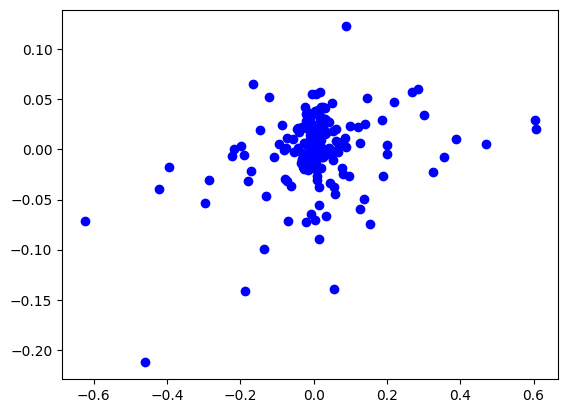

rmse: 0.019761843460581782


In [24]:
# Residuals against actual are clustered roughly around the mean (0) which is good
plt.scatter(final_gig_m_df['target'], preds, label='residuals', color='blue')
plt.show()
rmse = mean_squared_error(final_gig_m_df['target'], preds)
print(f"rmse: {rmse}")

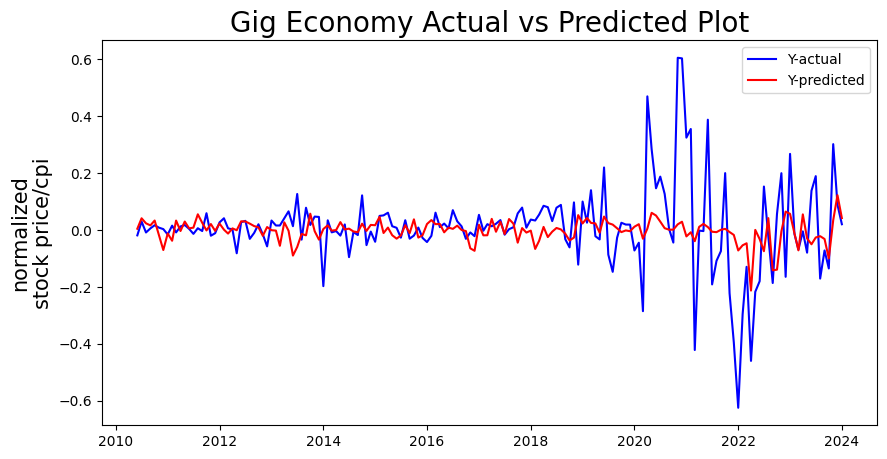

In [25]:
# Create the plot
fig, ax = plt.subplots(figsize=(10, 5))

# Plot first line
ax.plot(final_gig_m_df.index, final_gig_m_df['target'], label='Y-actual', color='blue')

# Plot second line
ax.plot(final_gig_m_df.index, preds, label='Y-predicted', color='red')

# Add y label and title
plt.ylabel("normalized\nstock price/cpi", rotation=90, fontsize=15)
plt.title("Gig Economy Actual vs Predicted Plot", fontsize=20)

# Show legend
plt.legend()

# Display the plot
plt.show()

In [26]:
# Gig data variance is 21x larger from 2017 to the end of 2023 compared to mid 2010 to 2017
split_time_in_half = int(len(final_gig_m_df['target'].index)/2)
start_time_index = final_gig_m_df.iloc[0].name
half_way_index = final_gig_m_df.iloc[split_time_in_half].name
end_time_index = final_gig_m_df.iloc[-1].name
before_gig_var = np.var(final_gig_m_df['target'].iloc[:split_time_in_half])
after_gig_var = np.var(final_gig_m_df['target'].iloc[split_time_in_half:])
magnitude_before_after_gig = int(after_gig_var/before_gig_var)
print(f"Gig Economy Variance for two groups.\nGroup 1 starting at {start_time_index} and ending at {half_way_index}: {before_gig_var}\nGroup 2 starting at {half_way_index} and ending at {end_time_index}: {after_gig_var}\nGroup 2 is approximately {magnitude_before_after_gig}x as big as Group 1")

Gig Economy Variance for two groups.
Group 1 starting at 2010-06-01 00:00:00 and ending at 2017-04-01 00:00:00: 0.0018973464265953817
Group 2 starting at 2017-04-01 00:00:00 and ending at 2024-01-01 00:00:00: 0.04176928560473447
Group 2 is approximately 22x as big as Group 1


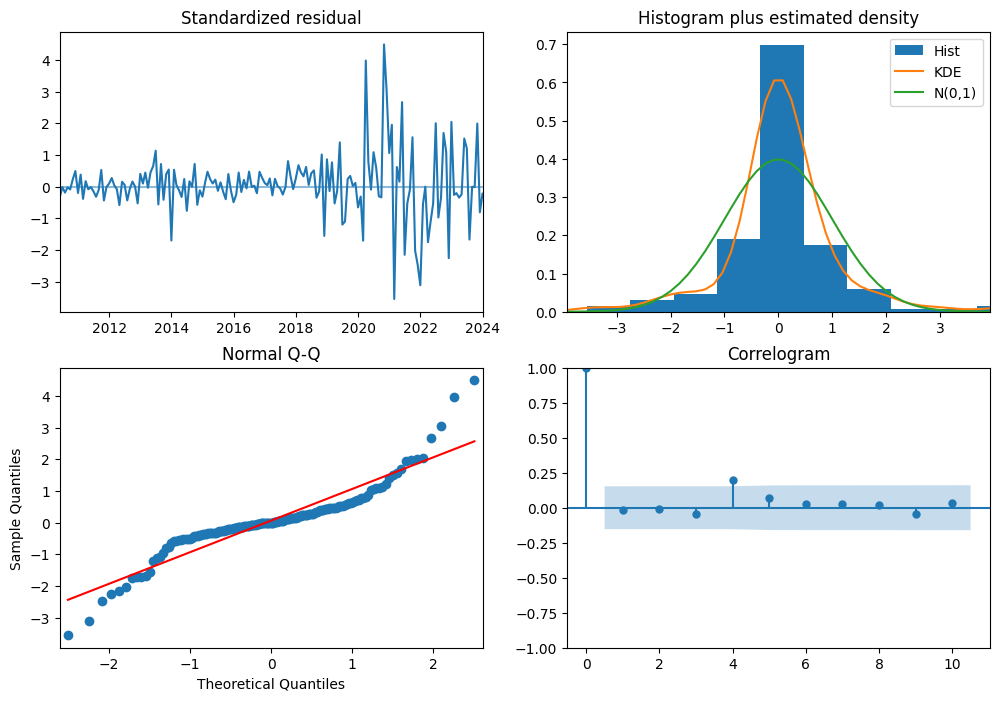

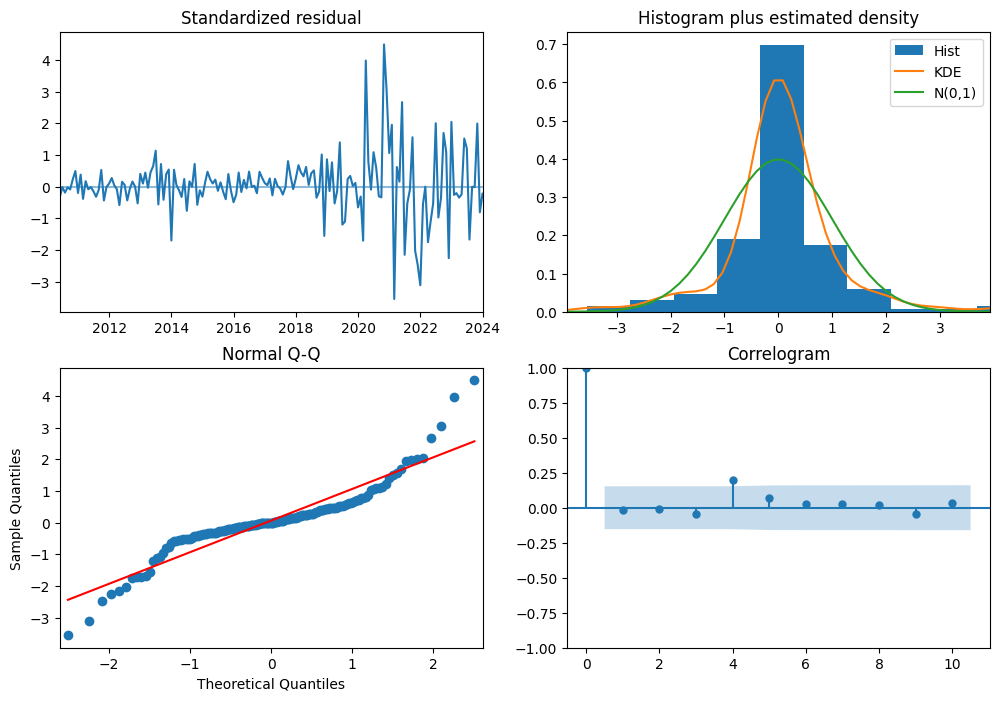

In [27]:
# Model looks to be good over all
best_gig_model_lst_[best_model_idx][1].plot_diagnostics(figsize=(12, 8))

In [28]:
exog_idx = int(sp500_model_df.iloc[0]['exog_idx'])
best_sp500_model_lst_ = list(best_sp500_model_lst)
for i, _ in enumerate(best_sp500_model_lst_):
    if _[0] == exog_idx:
        best_model_idx = i

preds = best_sp500_model_lst_[best_model_idx][1].predict(len(final_sp500_m_df[exog_cols[exog_idx]]), final_sp500_m_df[exog_cols[exog_idx]])
preds_gig = best_sp500_model_lst_[best_model_idx][1].predict(len(final_gig_m_df[exog_cols[exog_idx]]), final_gig_m_df[exog_cols[exog_idx]])

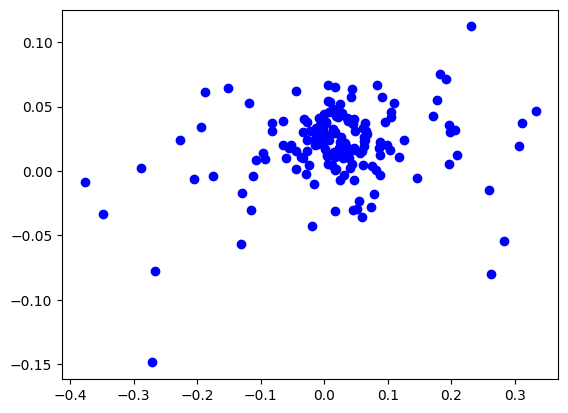

rmse: 0.011434820500313367


In [29]:
# Residuals against actual are clustered roughly around the mean (0) which is good
# However, they are less clustered compared to the gig data graph, which would make sense since the stock market is more diversified
plt.scatter(final_sp500_m_df['target'], preds, label='residuals', color='blue')
plt.show()
rmse = mean_squared_error(final_sp500_m_df['target'], preds)
print(f"rmse: {rmse}")

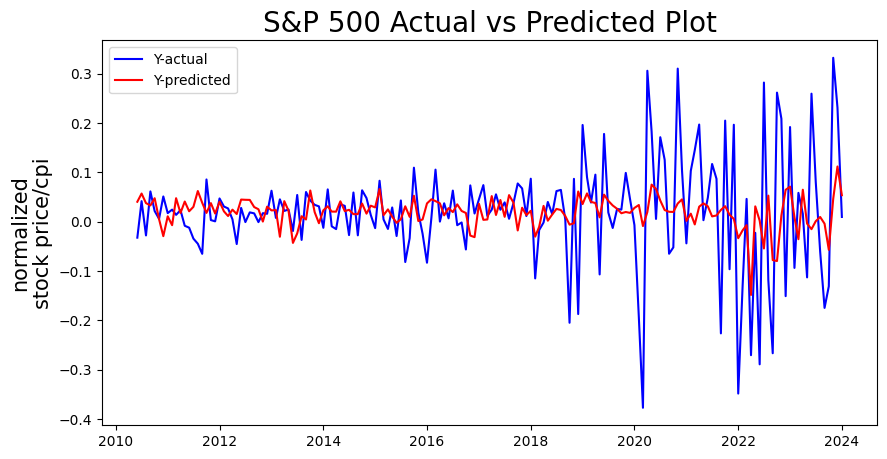

In [30]:
# Create the plot
fig, ax = plt.subplots(figsize=(10, 5))

# Plot first line
ax.plot(final_sp500_m_df.index, final_sp500_m_df['target'], label='Y-actual', color='blue')

# Plot second line
ax.plot(final_sp500_m_df.index, preds, label='Y-predicted', color='red')

# Add y label and title
plt.ylabel("normalized\nstock price/cpi", rotation=90, fontsize=15)
plt.title("S&P 500 Actual vs Predicted Plot", fontsize=20)

# Show legend
plt.legend()

# Display the plot
plt.show()

In [31]:
# S&P 500  data variance is 14x larger from 2017 to the end of 2023 compared to mid 2010 to 2017
split_time_in_half = int(len(final_sp500_m_df['target'].index)/2)
start_time_index = final_sp500_m_df.iloc[0].name
half_way_index = final_sp500_m_df.iloc[split_time_in_half].name
end_time_index = final_sp500_m_df.iloc[-1].name
before_sp500_var = np.var(final_sp500_m_df['target'].iloc[:split_time_in_half])
after_sp500_var = np.var(final_sp500_m_df['target'].iloc[split_time_in_half:])
magnitude_before_after_sp500 = int(after_sp500_var/before_sp500_var)
print(f"S&P500 Variance for two groups.\nGroup 1 starting at {start_time_index} and ending at {half_way_index}: {before_sp500_var}\nGroup 2 starting at {half_way_index} and ending at {end_time_index}: {after_sp500_var}\nGroup 2 is approximately {magnitude_before_after_sp500}x as big as Group 1")

S&P500 Variance for two groups.
Group 1 starting at 2010-06-01 00:00:00 and ending at 2017-04-01 00:00:00: 0.0015417773338636627
Group 2 starting at 2017-04-01 00:00:00 and ending at 2024-01-01 00:00:00: 0.02262921758975056
Group 2 is approximately 14x as big as Group 1


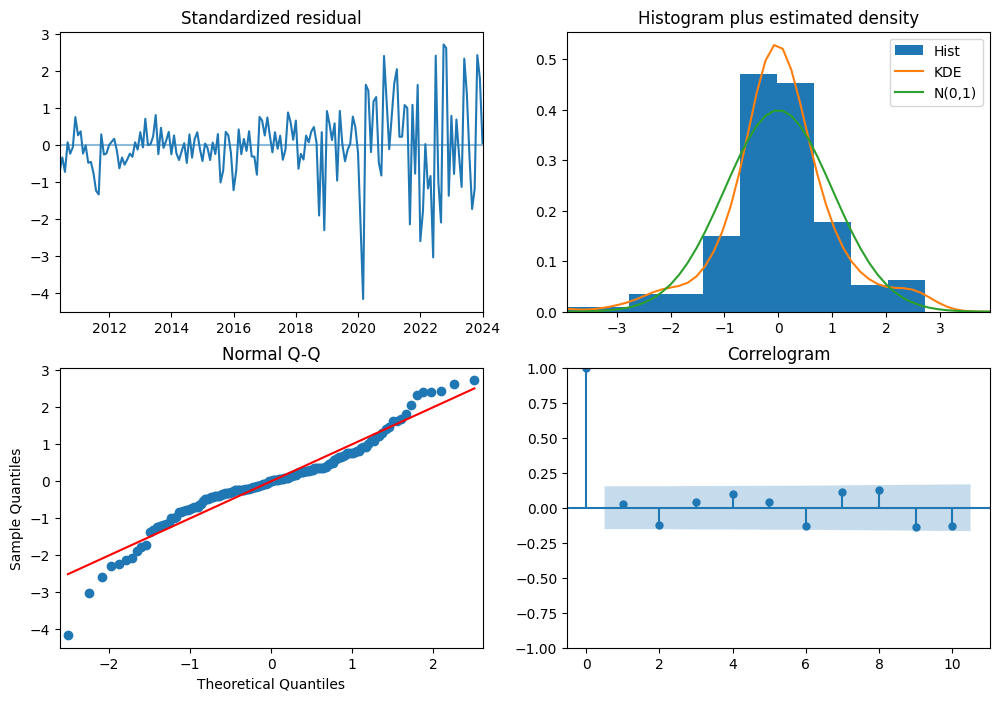

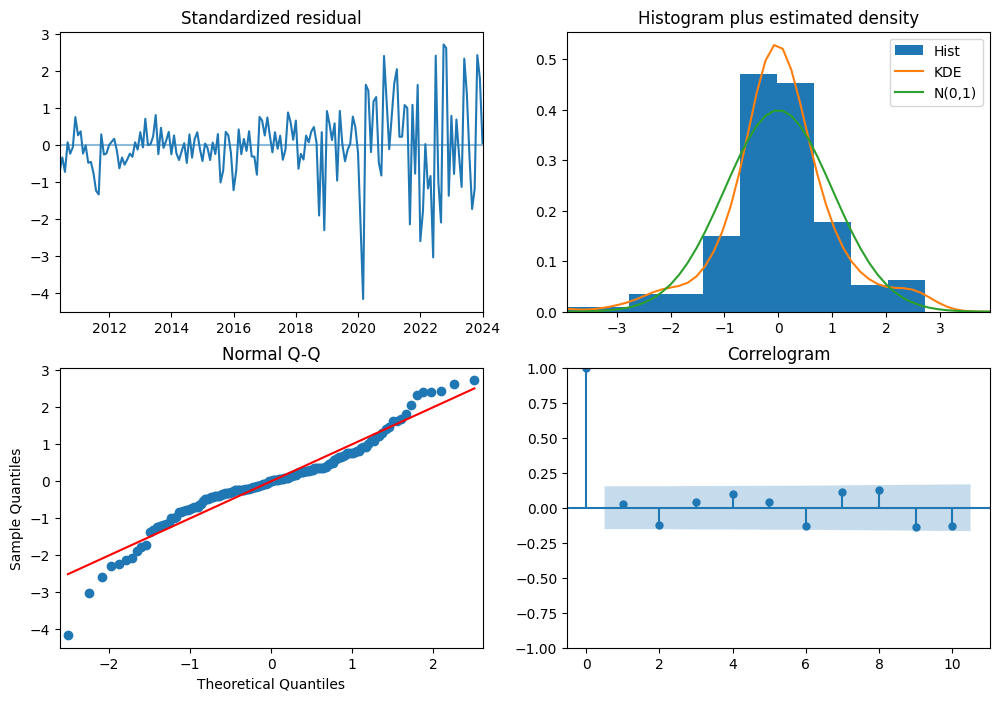

In [32]:
# Model looks to be good over all
best_sp500_model_lst_[best_model_idx][1].plot_diagnostics(figsize=(12, 8))